# Partie 3 : Classification d'Images & Hyperparamètres - SOLUTIONS

**Objectif :** Maîtriser le pipeline classique : Préparation → Modélisation → Évaluation.

**Outils :** Scikit-Learn (MLPClassifier), Dataset "Digits" (MNIST simplifié).


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


---

## Exercice 3.1 : Préparation des Données

Les réseaux de neurones sont très sensibles à l'échelle des données.


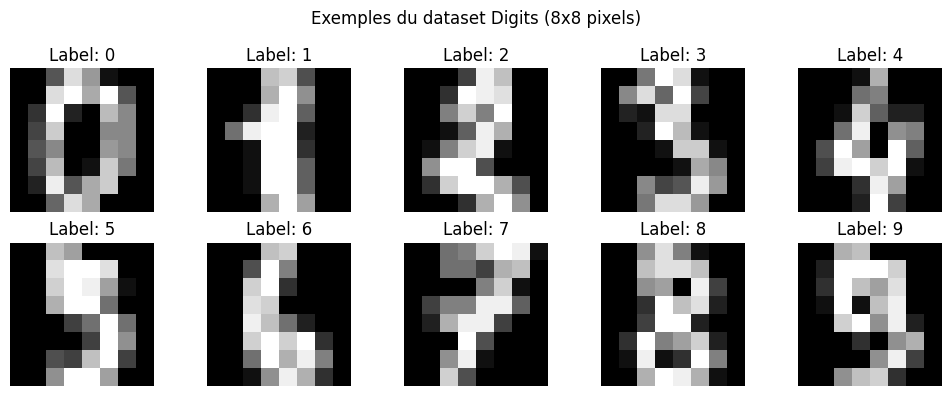

Shape des données: (1797, 64)
Valeurs des pixels: min=0.0, max=16.0


In [7]:
# Chargement des données
digits = load_digits()
X, y = digits.data, digits.target

# Visualisation de quelques exemples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("Exemples du dataset Digits (8x8 pixels)")
plt.tight_layout()
plt.show()

print(f"Shape des données: {X.shape}")
print(f"Valeurs des pixels: min={X.min()}, max={X.max()}")


In [8]:
# SOLUTION: Division des données (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} échantillons")
print(f"Test:  {X_test.shape[0]} échantillons")

# SOLUTION: Normalisation avec StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nAprès normalisation:")
print(f"  Moyenne: {X_train_scaled.mean():.4f} (≈ 0)")
print(f"  Écart-type: {X_train_scaled.std():.4f} (≈ 1)")


Train: 1437 échantillons
Test:  360 échantillons

Après normalisation:
  Moyenne: 0.0000 (≈ 0)
  Écart-type: 0.9763 (≈ 1)


### Pourquoi la normalisation est cruciale ?

La normalisation est **ESSENTIELLE** pour la descente de gradient car :

1. **CONVERGENCE PLUS RAPIDE** : Sans normalisation, les gradients peuvent être très différents selon les features.
2. **ÉVITE LES PROBLÈMES NUMÉRIQUES** : Des valeurs très grandes peuvent causer des overflow.
3. **LEARNING RATE UNIFORME** : Un seul learning rate fonctionne bien pour toutes les features.

---

## Exercice 3.2 : Architecture et Performance


In [9]:
# Architecture 1: Le Minimaliste (1 couche cachée, 5 neurones)
print("Entraînement du modèle Minimaliste (5 neurones)...")
mlp_mini = MLPClassifier(hidden_layer_sizes=(5,), max_iter=500, random_state=42)
mlp_mini.fit(X_train_scaled, y_train)
score_mini = mlp_mini.score(X_test_scaled, y_test)
print(f"  Score: {score_mini:.4f}")

# Architecture 2: Le Standard (1 couche cachée, 64 neurones)
print("\nEntraînement du modèle Standard (64 neurones)...")
mlp_standard = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42)
mlp_standard.fit(X_train_scaled, y_train)
score_standard = mlp_standard.score(X_test_scaled, y_test)
print(f"  Score: {score_standard:.4f}")

# Architecture 3: Le Profond (2 couches cachées, 64 neurones chacune)
print("\nEntraînement du modèle Profond (64, 64 neurones)...")
mlp_deep = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)
mlp_deep.fit(X_train_scaled, y_train)
score_deep = mlp_deep.score(X_test_scaled, y_test)
print(f"  Score: {score_deep:.4f}")

# Comparaison
print("\n" + "=" * 50)
print("COMPARAISON DES ARCHITECTURES")
print("=" * 50)
print(f"Minimaliste (5):     {score_mini:.4f}  ({score_mini*100:.1f}%)")
print(f"Standard (64):       {score_standard:.4f}  ({score_standard*100:.1f}%)")
print(f"Profond (64, 64):    {score_deep:.4f}  ({score_deep*100:.1f}%)")


Entraînement du modèle Minimaliste (5 neurones)...


/Users/gonthierlucas/miniconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Score: 0.9167

Entraînement du modèle Standard (64 neurones)...
  Score: 0.9806

Entraînement du modèle Profond (64, 64 neurones)...
  Score: 0.9750

COMPARAISON DES ARCHITECTURES
Minimaliste (5):     0.9167  (91.7%)
Standard (64):       0.9806  (98.1%)
Profond (64, 64):    0.9750  (97.5%)


---

## Exercice 3.3 : Analyse des Erreurs


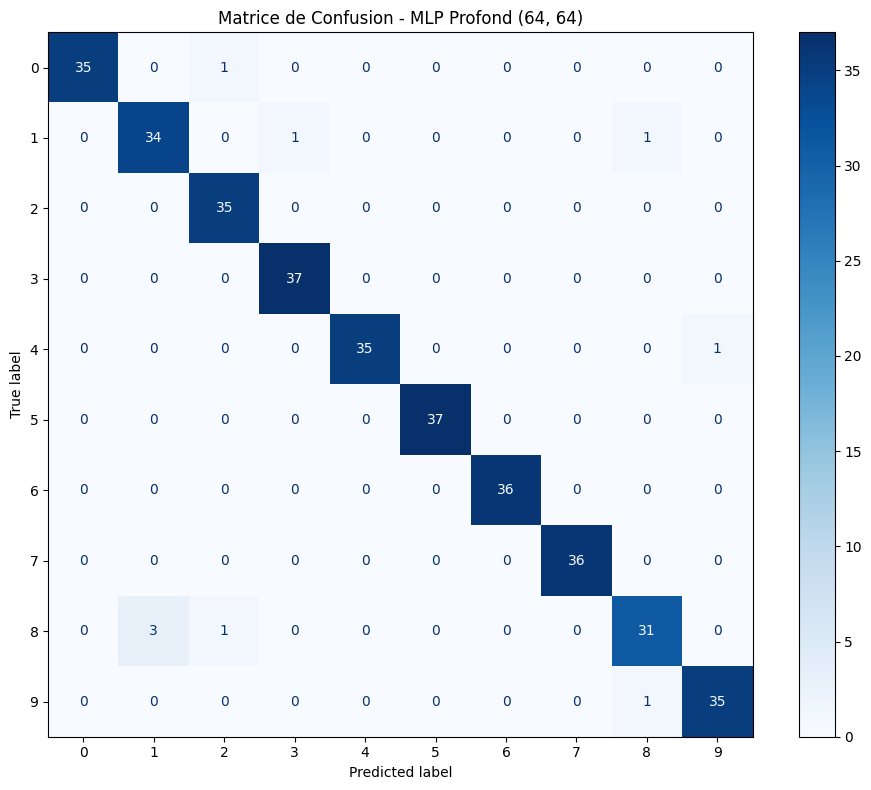


Top confusions les plus fréquentes:
  Chiffre 8 → prédit comme 1: 3 fois
  Chiffre 4 → prédit comme 9: 1 fois
  Chiffre 1 → prédit comme 3: 1 fois
  Chiffre 1 → prédit comme 8: 1 fois
  Chiffre 8 → prédit comme 2: 1 fois


In [10]:
# Utiliser le meilleur modèle
best_model = mlp_deep

# Prédictions sur le jeu de test
y_pred = best_model.predict(X_test_scaled)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Matrice de Confusion - MLP Profond (64, 64)")
plt.tight_layout()
plt.show()

# Identifier les chiffres les plus confondus
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
n_top = 5
indices = np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1][:n_top], cm.shape)

print("\nTop confusions les plus fréquentes:")
for i in range(n_top):
    true_digit = indices[0][i]
    pred_digit = indices[1][i]
    count = cm_no_diag[true_digit, pred_digit]
    if count > 0:
        print(f"  Chiffre {true_digit} → prédit comme {pred_digit}: {count} fois")
